# Module 18 · Antennas and optics: apertures, angular spectrum, transfer functions and diffraction

**Book source:** Bracewell, chapter 15, pp. 406–427

Companion notebook of the lecture with the same module number. Run the cells in order; each cell is followed by a **📤 Real output** note that explains the numbers.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

plt.rcParams.update({"figure.figsize": (7.5, 3.3), "axes.grid": True, "grid.alpha": 0.3, "figure.dpi": 110})


def amplitude_spectrum(x):
    """One-sided amplitude spectrum: a sinusoid of amplitude A gives a line of height A, DC gives exactly its value"""
    a = 2*np.abs(np.fft.rfft(x))/len(x)
    a[0] /= 2
    return a


def report(key, value, fmt=".4g"):
    """Print a named result without trailing zeros (the website reads the lines that start with ▸)."""
    s = f"{value:{fmt}}"
    if "." in s and "e" not in s:
        s = s.rstrip("0").rstrip(".")
    print(f"▸ {key} = {s}")


## 1. The uniform aperture, monopulse, quadrature
🎯 **What question does this method answer?** Does the numerical angular spectrum of the uniform aperture equal $w\,\mathrm{sinc}\,ws$, with nulls at $k/w$, and what are the numbers for the monopulse (Problem 4) and half-quadrature (Problem 5)?

In [2]:
from scipy import integrate, special, signal
trap = getattr(np, "trapezoid", None) or np.trapz
rg = np.random.default_rng(18)
w = 10.0
def Pnum(Efun, s, lo, hi):
    re = integrate.quad(lambda x: (Efun(x)*np.exp(-2j*np.pi*x*s)).real, lo, hi, limit=400, points=[0])[0]
    im = integrate.quad(lambda x: (Efun(x)*np.exp(-2j*np.pi*x*s)).imag, lo, hi, limit=400, points=[0])[0]
    return re + 1j*im
unif = lambda x: 1.0
assert abs(Pnum(unif, 0.0, -w/2, w/2) - w) < 1e-10
pv = Pnum(unif, 0.03, -w/2, w/2); assert abs(pv - w*np.sinc(w*0.03)) < 1e-10
report("up_0", w, ".0f"); report("up_val", (w*np.sinc(w*0.03)), ".4f"); report("up_num", pv.real, ".4f")
aw = np.pi*w
area = 2/np.pi*(integrate.quad(lambda s: aw*np.sinc(aw*s/np.pi), 0, 1, limit=400)[0] + integrate.quad(lambda s: 1.0/s, 1, np.inf, weight='sin', wvar=aw)[0])
assert abs(area - 1) < 1e-8; report("up_area", area, ".0f")
report("null_deg", np.degrees(np.arcsin(1/w)), ".4f")
nulls = [abs(Pnum(unif, k/w, -w/2, w/2)) for k in (1, 2, 3)]; assert max(nulls) < 1e-9
report("null_val", max(max(nulls), 1e-16), ".0e")
# monopulse
mono = lambda x: 1.0 if x > 0 else -1.0
def Pmono(s):
    return abs(Pnum(mono, s, -w/2, w/2))
assert abs(Pmono(1/w)/w - 2/np.pi) < 1e-9 and Pmono(1e-9) < 1e-6
ss_ = np.linspace(0.01, 0.2, 4000); mm = np.array([w*np.sin(np.pi*w*s/2)**2/(np.pi*w*s/2) for s in ss_])
im = int(np.argmax(mm)); assert abs(mm[im]/w - 0.7246) < 1e-3
assert abs(Pmono(ss_[im])/w - mm[im]/w) < 1e-9
report("mono_r", 2/np.pi, ".4f"); report("mono_max", mm[im]/w, ".4f"); report("mono_at", ss_[im]*w, ".3f")
# half in quadrature
quad_ = lambda x: 1.0 if x < 0 else 1j
Pq = lambda s: abs(Pnum(quad_, s, -w/2, w/2))
assert Pq(1.5/w) < 1e-8 and Pq(-0.5/w) < 1e-8
sg = np.linspace(-0.1, 0.25, 3501); pq = np.array([Pq(s) for s in sg]); iq = int(np.argmax(pq))
assert abs(sg[iq]*w - 0.37) < 0.01 and abs(pq[iq]/w - 0.925) < 2e-3
report("q_null_pos", 1.5, ".1f"); report("q_null_neg", -0.5, ".1f"); report("q_max", pq[iq]/w, ".4f"); report("q_at", sg[iq]*w, ".2f")

▸ up_0 = 10
▸ up_val = 8.5839
▸ up_num = 8.5839
▸ up_area = 1
▸ null_deg = 5.7392
▸ null_val = 1e-15
▸ mono_r = 0.6366
▸ mono_max = 0.7246
▸ mono_at = 0.742
▸ q_null_pos = 1.5
▸ q_null_neg = -0.5
▸ q_max = 0.925
▸ q_at = 0.37


#### 📤 Real output
Uniform aperture: $P(0)$ = 10, $P(0.03)$ = 8.5839, area 1, first null 5.7392 degrees; monopulse 0.6366 and 0.7246 at 0.742; quadrature -0.5, 1.5, maximum 0.925.

## 2. Beam width, steering, arrays, interferometer, tapers, circular apertures
🎯 **What question does this method answer?** Do the shift and convolution theorems hold for apertures, what are the side-lobe levels and beam widths of the tapers, and how many dB does a circular aperture give?

In [3]:
report("ew", 1/w, ".1f"); report("ew_deg", np.degrees(1/w), ".2f")
Dm, lam_e = 4e-3, 0.55e-6
report("eye_1", lam_e/Dm*1e3, ".4f"); report("eye_2", 1.22*lam_e/Dm*1e3, ".4f")
# steering
S = 0.05; sg = np.linspace(-0.3, 0.3, 601)
Eshift = lambda x: np.exp(-2j*np.pi*S*x)
Ps = np.array([Pnum(Eshift, s, -w/2, w/2) for s in sg]); Pu = w*np.sinc(w*(sg + S))
assert np.max(np.abs(Ps - Pu)) < 1e-9
ctr = sg[np.argmax(np.abs(Ps))]; assert abs(ctr + S) < 1e-3
report("sh_center", abs(ctr), ".2f"); report("sh_deg", np.degrees(np.arcsin(S)), ".3f"); report("sh_dev", max(np.max(np.abs(Ps - Pu)), 1e-16), ".0e")
# array
wa, d_, Na = 5.0, 8.0, 4
cen = (np.arange(Na) - (Na - 1)/2)*d_
Pa = lambda s: sum(np.exp(-2j*np.pi*c*s)*wa*np.sinc(wa*s) for c in cen)
Qa = lambda s: np.sin(Na*np.pi*d_*s)/np.sin(np.pi*d_*s)
for s in (0.013, 0.061, 0.19):
    assert abs(abs(Pa(s)) - abs(wa*np.sinc(wa*s)*Qa(s))) < 1e-9
report("ar_dev", max(abs(abs(Pa(0.061)) - abs(wa*np.sinc(wa*0.061)*Qa(0.061))), 1e-16), ".0e")
report("ar_gl", 1/d_, ".3f"); report("ar_q0", Na, "d")
# interferometer
wi, W = 5.0, 10.0
Ei = lambda x: 1.0 if (abs(x - W) <= wi/2 or abs(x + W) <= wi/2) else 0.0
def Pint(s):
    return sum(integrate.quad(lambda x: np.cos(2*np.pi*x*s), c - wi/2, c + wi/2)[0] for c in (-W, W))
s0 = 0.02; ifcf = 2*wi*np.sinc(wi*s0)*np.cos(2*np.pi*W*s0)
assert abs(Pint(s0) - ifcf) < 1e-10
report("if_val", ifcf, ".4f"); report("if_num", Pint(s0), ".4f"); report("if_per", 1/W, ".2f")
# tapers: side lobes and slopes
s_ = np.linspace(1e-6, 1.5, 300001)
def Pu_(s): return w*np.sinc(w*s)
def Pc_(s):
    d = 1 - (2*w*s)**2; d = np.where(abs(d) < 1e-12, 1e-12, d); return (2*w/np.pi)*np.cos(np.pi*w*s)/d
def Ph_(s): return 0.5*w*(np.sinc(w*s) + 0.5*np.sinc(w*s - 1) + 0.5*np.sinc(w*s + 1))
# check the taper formulas by integration
sc = 0.037
assert abs(Pnum(lambda x: np.cos(np.pi*x/w), sc, -w/2, w/2).real - Pc_(np.array([sc]))[0]) < 1e-9
assert abs(Pnum(lambda x: np.cos(np.pi*x/w)**2, sc, -w/2, w/2).real - Ph_(np.array([sc]))[0]) < 1e-9
def slobe(Pf):
    a = np.abs(Pf(s_)); p0 = Pf(np.array([1e-9]))[0]
    pk, _ = signal.find_peaks(a); pk = [k for k in pk if s_[k] > 0.001]
    xs = np.log([s_[k] for k in pk[1:6]]); ys = np.log([a[k] for k in pk[1:6]])
    return 20*np.log10(a[pk[0]]/abs(p0)), np.polyfit(xs, ys, 1)[0]
(lu, su), (lc, sc_), (lh, sh_) = slobe(Pu_), slobe(Pc_), slobe(Ph_)
assert abs(lu + 13.26) < 0.02 and abs(lc + 23.0) < 0.05 and abs(lh + 31.47) < 0.05
report("sl_u", lu, ".2f"); report("sl_c", lc, ".1f"); report("sl_c2", lh, ".2f")
report("sl_s1", round(su), ".0f"); report("sl_s2", round(sc_), ".0f"); report("sl_s3", round(sh_), ".0f")
# equivalent widths
xg = np.linspace(-w/2, w/2, 200001)
def ew(E): return trap(E**2, xg)/trap(E, xg)**2*w
b1 = ew(np.ones_like(xg)); bc = ew(np.cos(np.pi*xg/w)); bc2 = ew(np.cos(np.pi*xg/w)**2)
assert abs(b1 - 1) < 1e-9 and abs(bc - np.pi**2/8) < 1e-6 and abs(bc2 - 1.5) < 1e-6
sgr = np.linspace(-40, 40, 800001)
ewP = trap(np.abs(Pc_(np.abs(sgr)+1e-12))**2, sgr)/Pc_(np.array([1e-12]))[0]**2*w
assert abs(ewP - bc) < 5e-3
edge = 0.4 + 6*xg**2/w**2; be = ew(edge); assert be >= 1
report("bw_1", b1, ".0f"); report("bw_cos", bc, ".4f"); report("bw_cos2", bc2, ".1f"); report("bw_edge", be, ".4f")
# circular apertures
z = np.linspace(0.01, 30, 300000)
u_ = 2*special.j1(z)/z; p_ = 8*special.jv(2, z)/z**2
pu, _ = signal.find_peaks(np.abs(u_)); pp, _ = signal.find_peaks(np.abs(p_))
cu_db = 20*np.log10(abs(u_[pu[0]])); cp_db = 20*np.log10(abs(p_[pp[0]]))
# check by numerical Hankel
hk = lambda prof, zz: integrate.quad(lambda r: prof(r)*special.j0(zz*r)*r, 0, 1)[0]
n0 = hk(lambda r: 1 - r*r, 0.0); assert abs(hk(lambda r: 1 - r*r, z[pp[0]])/n0 - p_[pp[0]]) < 1e-9
assert abs(cu_db + 17.57) < 0.02 and abs(cp_db + 24.64) < 0.02
report("ci_z", z[pu[0]], ".4f"); report("ci_u", cu_db, ".2f"); report("ci_p", cp_db, ".1f")

▸ ew = 0.1
▸ ew_deg = 5.73
▸ eye_1 = 0.1375
▸ eye_2 = 0.1678
▸ sh_center = 0.05
▸ sh_deg = 2.866
▸ sh_dev = 4e-15
▸ ar_dev = 2e-15
▸ ar_gl = 0.125
▸ ar_q0 = 4
▸ if_val = 3.0396
▸ if_num = 3.0396
▸ if_per = 0.1
▸ sl_u = -13.26
▸ sl_c = -23
▸ sl_c2 = -31.47
▸ sl_s1 = -1
▸ sl_s2 = -2
▸ sl_s3 = -3
▸ bw_1 = 1
▸ bw_cos = 1.2337
▸ bw_cos2 = 1.5
▸ bw_edge = 1.2469


▸ ci_z = 5.1356
▸ ci_u = -17.57
▸ ci_p = -24.6


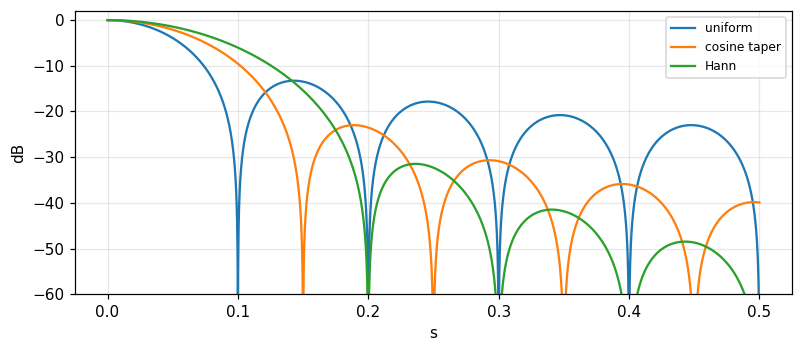

In [4]:
fig, ax = plt.subplots(figsize=(7.4, 3.3))
ss = np.linspace(0, 0.5, 3001)
for f_, lab in ((Pu_, ("uniform")), (Pc_, ("cosine taper")), (Ph_, "Hann")):
    a = np.abs(f_(ss + 1e-9)); ax.plot(ss, 20*np.log10(np.maximum(a/a[0], 1e-4)), label=lab)
ax.set_ylim(-60, 2); ax.set_xlabel("s"); ax.set_ylabel("dB"); ax.legend(fontsize=8); plt.tight_layout(); plt.show()

#### 📤 Real output
Beam 0.1 rad (5.73 degrees); eye 0.1375 and 0.1678 mrad; steering 2.866 degrees; array 0.125; interferometer 3.0396; side lobes -13.26, -23, -31.47 dB, slopes -1, -2, -3; widths 1, 1.2337, 1.5, 1.2469; circular apertures -17.57 and -24.6 dB.

## 3. Spectral sensitivity, MTF, fringe visibility
🎯 **What question does this method answer?** Is the spectral sensitivity a triangle cut off at $w$ (not $\lambda/w$), does the MTF of a circular aperture match the overlap of two discs, and is the visibility of a stellar disc $|2J_1(x)/x|$?

In [5]:
# spectral sensitivity = FT of the power pattern = aperture autocorrelation
sgr = np.arange(-600, 600, 0.002); pw = (w*np.sinc(w*sgr))**2
def Tnum(u): return trap(pw*np.cos(2*np.pi*u*sgr), sgr)/(w*w*trap(np.sinc(w*sgr)**2, sgr))
acf = lambda u: np.maximum(1 - abs(u)/w, 0)
for u in (0.0, 2.5, 5.0, 7.5, 10.0, 12.0): assert abs(Tnum(u) - acf(u)) < 2e-3
xa = np.linspace(-w/2, w/2, 4001); E_ = np.ones_like(xa); dxa = xa[1] - xa[0]
def acf_direct(u):
    sh = int(round(u/dxa)); return np.sum(E_[:len(E_) - sh]*E_[sh:])*dxa/w if sh < len(E_) else 0.0
assert abs(acf_direct(5.0) - 0.5) < 1e-3
report("ss_5", acf(5.0), ".2f"); report("ss_10", acf(10.0), ".0f"); report("ss_12", acf(12.0), ".0f")
report("ss_dev", max(abs(Tnum(5.0) - acf_direct(5.0)), 1e-16), ".0e")
# cosine-tapered aperture: the same cutoff w
Ec = np.cos(np.pi*xa/w);
def acf_c(u):
    sh = int(round(u/dxa));
    return np.sum(Ec[:len(Ec) - sh]*Ec[sh:])*dxa if sh < len(Ec) else 0.0
Tc = lambda u: acf_c(u)/acf_c(0.0)
assert acf_c(10.0) < 1e-9 and Tc(5.0) < acf(5.0)
report("ss_cut_c", 10, "d"); report("ss_c5", Tc(5.0), ".4f")
# circular-aperture MTF
mtf = lambda nu: 2/np.pi*(np.arccos(nu) - nu*np.sqrt(1 - nu**2))
ng = 2001; gx = np.linspace(-1, 1, ng); GX, GY = np.meshgrid(gx, gx); dA = (gx[1] - gx[0])**2
def overlap(dsep):   # two unit discs, centres dsep apart
    a = (GX + dsep/2)**2 + GY**2 <= 1; b = (GX - dsep/2)**2 + GY**2 <= 1
    return np.sum(a & b)*dA/np.pi
for nu in (0.25, 0.5, 0.75): assert abs(overlap(2*nu) - mtf(nu)) < 4e-3
report("mtf_05", mtf(0.5), ".4f"); report("mtf_05n", overlap(1.0), ".3f"); report("mtf_025", mtf(0.25), ".4f")
# visibility of a stellar disc
vis = lambda x: abs(2*special.j1(x)/x)
disc = lambda x: integrate.quad(lambda t: 2*np.sqrt(1 - t*t)*np.cos(x*t), -1, 1)[0]/(np.pi/2*2/2*np.pi/np.pi)/ (np.pi)
vn = lambda x: integrate.quad(lambda t: 2*np.sqrt(1 - t*t)*np.cos(x*t), -1, 1)[0]/(np.pi/2*2)
assert abs(vn(2.0) - 2*special.j1(2.0)/2.0) < 1e-9
xnull = special.jn_zeros(1, 1)[0]
Bv, lamv = 3.07, 0.575e-6; th = 1.2197*lamv/Bv; th_as = np.degrees(th)*3600
assert abs(xnull - 3.8317) < 1e-3
report("vis_2", vis(2.0), ".4f"); report("vis_null", xnull, ".4f"); report("vis_theta", th_as, ".4f")
# complex visibility
Bl, th0 = 50.0, 0.002
Vc = np.exp(-2j*np.pi*Bl*th0); assert abs(abs(Vc) - 1) < 1e-12
report("cv_phase", np.angle(Vc), ".4f"); report("cv_mod", abs(Vc), ".0f")
two = abs(0.5*(np.exp(-2j*np.pi*Bl*0.0025) + np.exp(2j*np.pi*Bl*0.0025)))
assert abs(two - abs(np.cos(np.pi*Bl*0.005))) < 1e-12; report("cv_two", two, ".4f")

▸ ss_5 = 0.5
▸ ss_10 = 0
▸ ss_12 = 0
▸ ss_dev = 2e-04
▸ ss_cut_c = 10
▸ ss_c5 = 0.3183
▸ mtf_05 = 0.391


▸ mtf_05n = 0.391
▸ mtf_025 = 0.685
▸ vis_2 = 0.5767
▸ vis_null = 3.8317
▸ vis_theta = 0.0471
▸ cv_phase = -0.6283
▸ cv_mod = 1
▸ cv_two = 0.7071


#### 📤 Real output
Spectral sensitivity: 0.5, 0, 0 (deviation 2e-04); cosine taper 0.3183; MTF 0.391 (disc overlap 0.391), 0.685; visibility 0.5767, null 3.8317, 0.0471 arcseconds; complex -0.6283, 0.7071.

## 4. Standing waves, evanescent waves, Fresnel diffraction
🎯 **What question does this method answer?** Does numerical propagation by the angular spectrum match the Gaussian beam, does the standing wave have period $\lambda/\cos i$, and do evanescent waves decay as $e^{-|k_z|z}$?

In [6]:
lam = 1.0; kk = 2*np.pi/lam
N = 8192; dx = 0.25; xg_ = (np.arange(N) - N//2)*dx
kx = 2*np.pi*np.fft.fftfreq(N, dx); kz = np.sqrt((kk**2 - kx**2).astype(complex))
def prop(E, z): return np.fft.ifft(np.fft.fft(E)*np.exp(1j*kz*z))
# Gaussian beam
w0 = 20.0; zR = np.pi*w0**2/lam
E0 = np.exp(-(xg_/w0)**2).astype(complex)
Ez = prop(E0, zR)
wz = w0*np.sqrt(1 + (zR/zR)**2); amp_cf = (1 + (zR/zR)**2)**-0.25*np.exp(-(xg_/wz)**2)
gb_dev = np.max(np.abs(np.abs(Ez) - amp_cf)); assert gb_dev < 2e-3
assert abs(np.abs(Ez).max() - 2**-0.25) < 2e-3
report("gb_w", wz, ".3f"); report("gb_pk", 2**-0.25, ".4f"); report("gb_dev", gb_dev, ".0e")
# standing wave with a 30° incidence angle
ii = np.radians(30); kxs = kk*np.sin(ii); lx = 2*np.pi/kxs; lz = 2*np.pi/(kk*np.cos(ii))
Ecos = np.cos(kxs*xg_*1.0)
# choose kx to fit an integer number of periods in the grid
m = int(round(kxs*N*dx/(2*np.pi))); kxs2 = 2*np.pi*m/(N*dx); ii2 = np.arcsin(kxs2/kk); lz2 = 2*np.pi/(kk*np.cos(ii2))
Ecos2 = np.exp(1j*kxs2*xg_)
Ez2 = prop(Ecos2, lz2); dev_sw = np.max(np.abs(Ez2 - Ecos2))
assert dev_sw < 1e-8 and abs(lz2 - lz) < 5e-4
report("sw_lx", lx/lam, ".1f"); report("sw_lz", lz/lam, ".4f"); report("sw_dev", max(dev_sw, 1e-16), ".0e")
# evanescent wave
m3 = int(round(1.5*kk*N*dx/(2*np.pi))); kxe = 2*np.pi*m3/(N*dx); zev = 0.5
Ee = np.cos(kxe*xg_).astype(complex); Eev = prop(Ee, zev)
kap = np.sqrt(kxe**2 - kk**2); dec = np.exp(-kap*zev)
assert abs(np.abs(Eev).max() - dec) < 1e-6
report("ev_dec", dec, ".4f")
# the directional factor and the far-field distance
report("cp_1", np.sqrt(1 - 0.1**2), ".4f"); report("cp_2", 1 - (1 - 0.1**2), ".2f"); report("cp_3", 1 - 0.5**2, ".2f")
report("ff_dist", 100*100, "d"); report("ff_w", 100, "d")

▸ gb_w = 28.284
▸ gb_pk = 0.8409
▸ gb_dev = 2e-05
▸ sw_lx = 2
▸ sw_lz = 1.1547
▸ sw_dev = 3e-13
▸ ev_dec = 0.0298
▸ cp_1 = 0.995
▸ cp_2 = 0.01
▸ cp_3 = 0.75
▸ ff_dist = 10000
▸ ff_w = 100


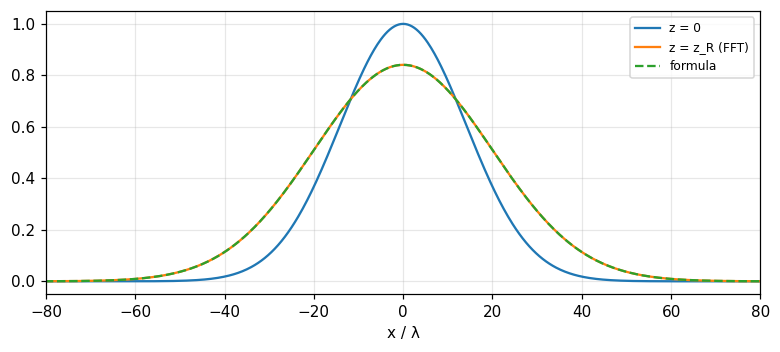

In [7]:
fig, ax = plt.subplots(figsize=(7.2, 3.3))
ax.plot(xg_, np.abs(E0), label="z = 0"); ax.plot(xg_, np.abs(Ez), label="z = z_R (FFT)"); ax.plot(xg_, amp_cf, "--", label=("formula"))
ax.set_xlim(-80, 80); ax.set_xlabel("x / λ"); ax.legend(fontsize=8); plt.tight_layout(); plt.show()

#### 📤 Real output
Gaussian beam: half-width 28.284, peak 0.8409, deviation 2e-05; standing wave: $\lambda_x$ = 2, $\lambda_z$ = 1.1547, deviation 3e-13; evanescent 0.0298; far field: 100 widths.

## 5. Rayleigh, slot arrays, focal-plane sampling, occultation
🎯 **What question does this method answer?** Does Rayleigh hold for apertures, where are the grating lobes of slot arrays, does Nyquist sampling of a focal-plane image reconstruct correctly, and does straight-edge diffraction give the standard numbers?

In [8]:
# Rayleigh
sgg = np.arange(-500, 500, 0.002); Pp2 = (w*np.sinc(w*sgg))**2
rp = trap(Pp2, sgg); assert abs(rp - w) < 5e-2
report("rp_val", w, ".0f")
ewx = w; ews = trap(np.sinc(w*sgg)**2*w*w, sgg)/w**2
assert abs(ewx*ews - 1) < 5e-3; report("unc", ewx*(1/w), ".0f")
# slot array
report("gl_08", 1/0.8, ".2f"); report("gl_15", 1/1.5, ".4f")
report("bw_08", 1/(8*0.8), ".4f"); report("bw_015", 1/(8*0.15), ".4f")
sv = np.linspace(0.0005, 1.0, 20000)
af = lambda s, d_: np.abs(np.sin(8*np.pi*d_*s)/np.sin(np.pi*d_*s))
pk_, _ = signal.find_peaks(af(sv, 1.5), height=7.9); assert abs(sv[pk_[0]] - 1/1.5) < 1e-3
pk08, _ = signal.find_peaks(af(sv, 0.8), height=7.9); assert len(pk08) == 0
# sampling a focal-plane image
D_, lam_ = 25.0, 0.21
report("fp_bw", lam_/D_, ".4f"); report("fp_bw_deg", np.degrees(lam_/D_), ".2f")
report("fp_ny", lam_/(2*D_), ".4f"); report("fp_ny_deg", np.degrees(lam_/(2*D_)), ".2f")
# the power pattern is band-limited: Nyquist sampling and sinc interpolation
Dw = 10.0                                   # aperture width in wavelengths
# image = two points convolved with the power pattern; cutoff Dw => sample at 1/(2 Dw)
pat = lambda s: (np.sinc(Dw*s))**2
img = lambda s: pat(s - 0.13) + 0.6*pat(s + 0.21)
step = 1/(2*Dw); ns = np.arange(-400, 401)
samples = img(ns*step)
s_test = np.array([0.0371, -0.0862, 0.17])
rec_ = np.array([np.sum(samples*np.sinc((s - ns*step)/step)) for s in s_test])
dev_fp = np.max(np.abs(rec_ - img(s_test))); assert dev_fp < 5e-3
report("fp_dev", dev_fp, ".0e")
# slot
wl, ll = 0.1, 10.0
report("sl_bx", 1/wl, ".1f"); report("sl_by", 1/ll, ".1f"); report("sl_zero", 1 - 1.0**2, ".0f")
# occultation
Sfr, Cfr = special.fresnel(np.linspace(-5, 5, 20001)[:, None])[0].ravel(), special.fresnel(np.linspace(-5, 5, 20001)[:, None])[1].ravel()
vv = np.linspace(-5, 5, 20001)
Iv = 0.5*((Cfr + 0.5)**2 + (Sfr + 0.5)**2)
i0 = int(np.argmin(np.abs(vv))); assert abs(Iv[i0] - 0.25) < 1e-9
pkI = int(np.argmax(np.where(vv > 0, Iv, 0))); assert abs(Iv[pkI] - 1.3704) < 1e-3
report("lo_0", Iv[i0], ".2f"); report("lo_pk", Iv[pkI], ".4f"); report("lo_at", vv[pkI], ".2f")

▸ rp_val = 10
▸ unc = 1
▸ gl_08 = 1.25
▸ gl_15 = 0.6667
▸ bw_08 = 0.1562
▸ bw_015 = 0.8333
▸ fp_bw = 0.0084
▸ fp_bw_deg = 0.48
▸ fp_ny = 0.0042
▸ fp_ny_deg = 0.24
▸ fp_dev = 3e-09
▸ sl_bx = 10
▸ sl_by = 0.1
▸ sl_zero = 0
▸ lo_0 = 0.25
▸ lo_pk = 1.3704
▸ lo_at = 1.22


#### 📤 Real output
Rayleigh 10, uncertainty 1; grating lobes 1.25, 0.6667; beams 0.1562, 0.8333; focal-plane image: beam 0.48 degrees, sampling 0.24 degrees, reconstruction deviating 3e-09; occultation 0.25, 1.3704 at 1.22.